In [1]:
# Imports
import polars as pl
from matplotlib import pyplot as plt
%matplotlib inline
import glob

In [2]:
# Import robot timestamp results
# Get all CSV files from the directory
moderate_load_files = glob.glob("../timestamp_results/thesis-eval-experiments/moderate-load/robot-states-#1/*.csv")
high_load_files = glob.glob("../timestamp_results/thesis-eval-experiments/high-load/robot-states-#1/*.csv")
# Read and combine all CSV files
dfs = [pl.read_csv(file, has_header=True, separator=',') for file in moderate_load_files]
moderate_load_df = pl.concat(dfs)
dfs = [pl.read_csv(file, has_header=True, separator=',') for file in high_load_files]
high_load_df = pl.concat(dfs)

# Import completed order timestamp files
moderate_load_completed_file = glob.glob("../timestamp_results/thesis-eval-experiments/moderate-load/kitchen-states-#1/*completed*.csv")
high_load_completed_file = glob.glob("../timestamp_results/thesis-eval-experiments/high-load/kitchen-states-#1/*completed*.csv")
# Import received order timestamp files
moderate_load_received_file = glob.glob("../timestamp_results/thesis-eval-experiments/moderate-load/kitchen-states-#1/*received*.csv")
high_load_received_file = glob.glob("../timestamp_results/thesis-eval-experiments/high-load/kitchen-states-#1/*received*.csv")
# Read and combine all CSV files
moderate_load_completed_df = pl.read_csv(moderate_load_completed_file[0], has_header=True, separator=',')
high_load_completed_df = pl.read_csv(high_load_completed_file[0], has_header=True, separator=',')
moderate_load_received_df = pl.read_csv(moderate_load_received_file[0], has_header=True, separator=',')
high_load_received_df = pl.read_csv(high_load_received_file[0], has_header=True, separator=',')

In [3]:
# Get t0 reference timestamp from received order timestamps for moderate load
t0_reference_moderate = moderate_load_received_df.filter(pl.col('ReceivedOrdersCount') == 1)['Timestamp'][0]
# Set t0 reference moderate load
moderate_load_df = moderate_load_df.with_columns(
    pl.when(pl.col('Timestamp') - t0_reference_moderate < 0).then(0).otherwise(pl.col('Timestamp') - t0_reference_moderate).alias('Timestamp')
)
moderate_load_completed_df = moderate_load_completed_df.with_columns(
    pl.when(pl.col('Timestamp') - t0_reference_moderate < 0).then(0).otherwise(pl.col('Timestamp') - t0_reference_moderate).alias('Timestamp')
)
moderate_load_received_df = moderate_load_received_df.with_columns(
    pl.when(pl.col('Timestamp') - t0_reference_moderate < 0).then(0).otherwise(pl.col('Timestamp') - t0_reference_moderate).alias('Timestamp')
)
# Get t0 reference timestamp from received order timestamps for high load
t0_reference_high = high_load_received_df.filter(pl.col('ReceivedOrdersCount') == 1)['Timestamp'][0]
# Set t0 reference high load
high_load_df = high_load_df.with_columns(
    pl.when(pl.col('Timestamp') - t0_reference_high < 0).then(0).otherwise(pl.col('Timestamp') - t0_reference_high).alias('Timestamp')
)
high_load_completed_df = high_load_completed_df.with_columns(
    pl.when(pl.col('Timestamp') - t0_reference_high < 0).then(0).otherwise(pl.col('Timestamp') - t0_reference_high).alias('Timestamp')
)
high_load_received_df = high_load_received_df.with_columns(
    pl.when(pl.col('Timestamp') - t0_reference_high < 0).then(0).otherwise(pl.col('Timestamp') - t0_reference_high).alias('Timestamp')
)

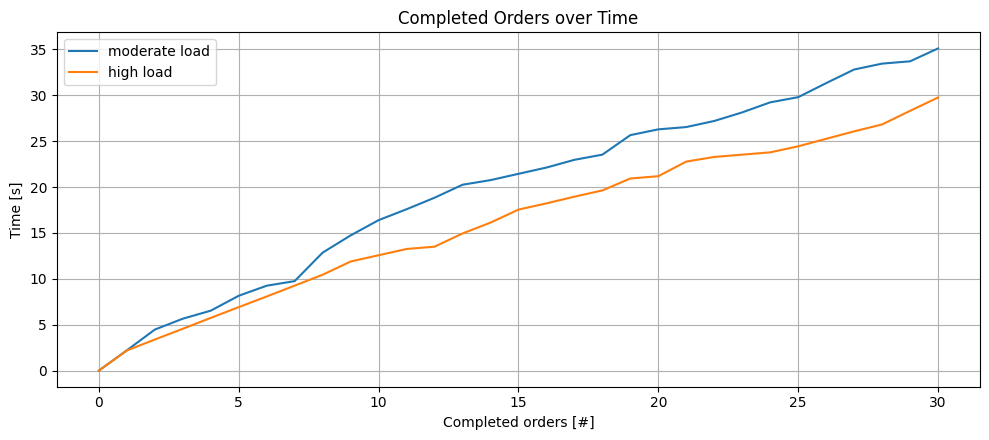

In [4]:
timestamp_dfs = [moderate_load_completed_df, high_load_completed_df]
labels = ['moderate load', 'high load']

# Plot all three with legend
plt.figure(figsize=(10, 4.5))
for timestamp_df,label in zip(timestamp_dfs,labels):
    plt.plot(timestamp_df['CompletedOrdersCount'], timestamp_df['Timestamp'] / 1e9, label=label)
plt.xlabel('Completed orders [#]')
plt.ylabel('Time [s]')
plt.title('Completed Orders over Time')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



In [5]:
# Get values using select() and .item() to extract scalars
makespan_moderate = moderate_load_completed_df.select(pl.col('Timestamp').max()).item() / 1e9
print("moderate load makespan: {0:.3f} s".format(makespan_moderate))

avg_interval_moderate = (
    moderate_load_completed_df
    .filter(pl.col('Timestamp') > 0)
    .select(pl.col('Timestamp').diff().mean())
    .item()
) / 1e9
print("moderate load average interval: {0:.3f} s".format(avg_interval_moderate))

makespan_high = high_load_completed_df.select(pl.col('Timestamp').max()).item() / 1e9
print("high load makespan: {0:.3f} s".format(makespan_high))

avg_interval_high = (
    high_load_completed_df
    .filter(pl.col('Timestamp') > 0)
    .select(pl.col('Timestamp').diff().mean())
    .item()
) / 1e9
print("high load average interval: {0:.3f} s".format(avg_interval_high))

moderate load makespan: 35.093 s
moderate load average interval: 1.134 s
high load makespan: 29.750 s
high load average interval: 0.950 s


Average share percentages for moderate load:
shape: (4, 3)
┌────────────────────┬─────────────┬─────────────────┐
│ STATE_NAME         ┆ DURATION_NS ┆ AverageSharePct │
│ ---                ┆ ---         ┆ ---             │
│ str                ┆ i64         ┆ f64             │
╞════════════════════╪═════════════╪═════════════════╡
│ RETOOLING          ┆ 24832855000 ┆ 17.690526       │
│ COOKING            ┆ 59240139000 ┆ 42.201722       │
│ IDLING             ┆ 48087840000 ┆ 34.257004       │
│ WAITING_FOR_PICKUP ┆ 8212914000  ┆ 5.850748        │
└────────────────────┴─────────────┴─────────────────┘



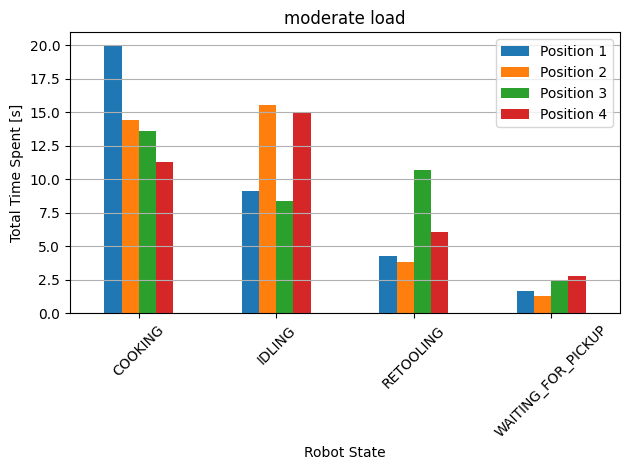

Total time recorded for Position 1: 35.093 seconds
IDLING share for Position 1: 9.159 seconds (26.10%)
COOKING share for Position 1: 19.962 seconds (56.88%)
RETOOLING share for Position 1: 4.293 seconds (12.23%)
WAITING_FOR_PICKUP share for Position 1: 1.679 seconds (4.78%)

Total time recorded for Position 2: 35.093 seconds
IDLING share for Position 2: 15.566 seconds (44.36%)
COOKING share for Position 2: 14.440 seconds (41.15%)
RETOOLING share for Position 2: 3.823 seconds (10.89%)
WAITING_FOR_PICKUP share for Position 2: 1.264 seconds (3.60%)

Total time recorded for Position 3: 35.093 seconds
IDLING share for Position 3: 8.379 seconds (23.88%)
COOKING share for Position 3: 13.578 seconds (38.69%)
RETOOLING share for Position 3: 10.670 seconds (30.40%)
WAITING_FOR_PICKUP share for Position 3: 2.467 seconds (7.03%)

Total time recorded for Position 4: 35.093 seconds
IDLING share for Position 4: 14.983 seconds (42.70%)
COOKING share for Position 4: 11.260 seconds (32.09%)
RETOOLING sh

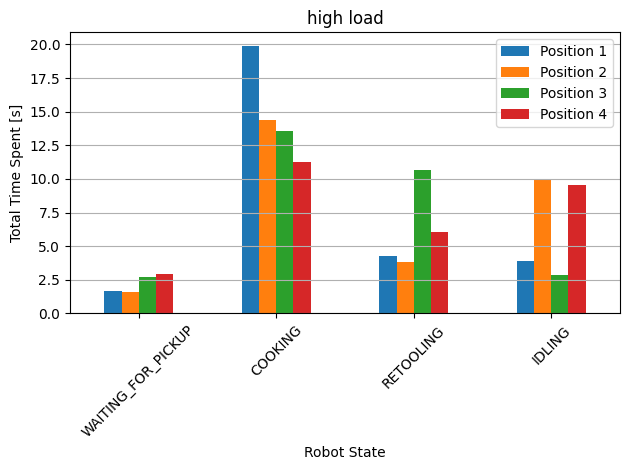

Total time recorded for Position 1: 29.750 seconds
IDLING share for Position 1: 3.873 seconds (13.02%)
COOKING share for Position 1: 19.901 seconds (66.89%)
RETOOLING share for Position 1: 4.293 seconds (14.43%)
WAITING_FOR_PICKUP share for Position 1: 1.682 seconds (5.66%)

Total time recorded for Position 2: 29.750 seconds
IDLING share for Position 2: 9.911 seconds (33.31%)
COOKING share for Position 2: 14.406 seconds (48.42%)
RETOOLING share for Position 2: 3.818 seconds (12.83%)
WAITING_FOR_PICKUP share for Position 2: 1.615 seconds (5.43%)

Total time recorded for Position 3: 29.750 seconds
IDLING share for Position 3: 2.855 seconds (9.60%)
COOKING share for Position 3: 13.564 seconds (45.60%)
RETOOLING share for Position 3: 10.640 seconds (35.77%)
WAITING_FOR_PICKUP share for Position 3: 2.690 seconds (9.04%)

Total time recorded for Position 4: 29.750 seconds
IDLING share for Position 4: 9.532 seconds (32.04%)
COOKING share for Position 4: 11.236 seconds (37.77%)
RETOOLING share

In [18]:
from enum import IntEnum
from pathlib import Path

# State enums
class RobotState(IntEnum):
    IDLING = 0
    COOKING = 1
    RETOOLING = 2
    WAITING_FOR_PICKUP = 3
    REARRANGING = 4
    RECONFIGURING = 5

# helper mapping from numeric state to name
ROBOT_STATE_NAME = {state.value: state.name for state in RobotState}


def export_combined_pd_for_tikz(combined_pd, title, out_dir='tikz_csv'):
    """Export wide and long CSVs for LaTeX/TikZ plotting."""
    export_dir = Path(out_dir)
    export_dir.mkdir(parents=True, exist_ok=True)

    safe_title = title.lower().replace(' ', '_')
    combined_pd.to_csv(
        export_dir / f'combined_pd_{safe_title}.csv',
        index=True,
        index_label='STATE_NAME'
    )

    combined_long = (
        combined_pd
        .reset_index()
        .melt(id_vars='STATE_NAME', var_name='Position', value_name='Duration_s')
    )
    combined_long.to_csv(
        export_dir / f'combined_pd_{safe_title}_long.csv',
        index=False
    )


# Method to analyze time spent in each state per robot position
def analyze_time_spent_per_state(robot_stats_df, simulation_end_time=None):
    # Sort by timestamp
    df = robot_stats_df.sort('Timestamp')

    # Detect state changes using shift
    df = df.with_columns(
        pl.col('State').shift(1).alias('prev_state')
    )

    # Group consecutive equal states
    df = df.with_columns(
        (pl.col('State') != pl.col('prev_state')).fill_null(True).cast(pl.Int32).cum_sum().alias('state_group')
    )

    # Keep one row per consecutive state run, preserving the original segment boundaries
    grouped = (
        df
        .group_by('state_group')
        .agg(
            pl.col('State').first().alias('State'),
            pl.col('Timestamp').first().alias('start_timestamp')
        )
        .sort('state_group')
        .with_columns(
            pl.col('start_timestamp').shift(-1).alias('next_start_timestamp')
        )
        .with_columns(
            pl.when(pl.col('next_start_timestamp').is_null())
            .then(df.select(pl.col('Timestamp').last()).item())
            .otherwise(pl.col('next_start_timestamp'))
            .alias('end_timestamp')
        )
        .with_columns(
            (pl.col('end_timestamp') - pl.col('start_timestamp')).alias('DURATION_NS')
        )
        .with_columns(
            pl.col('State').cast(pl.Int64).replace_strict(ROBOT_STATE_NAME).alias('STATE_NAME')
        )
        .select(['STATE_NAME', 'DURATION_NS'])
    )

    if simulation_end_time is not None:
        last_timestamp = robot_stats_df.select(pl.col('Timestamp').max()).item()
        if last_timestamp < simulation_end_time and grouped.height > 0:
            gap_ns = simulation_end_time - last_timestamp
            grouped = grouped.with_row_index('row_nr').with_columns(
                pl.when(
                    (pl.col('row_nr') == grouped.height - 1) & (pl.col('STATE_NAME') == 'IDLING')
                )
                .then(pl.col('DURATION_NS') + gap_ns)
                .otherwise(pl.col('DURATION_NS'))
                .alias('DURATION_NS')
            ).drop('row_nr')

    return grouped

def compute_state_share(combined_df, total_positions, title):
    # Add total time per state across all positions for percentage calculation
    total_time_per_position = combined_df.group_by('Position').agg(pl.col('DURATION_NS').sum())
    # Check if column DURATION_NS equals in all rows of total_time_per_position
    if not total_time_per_position.select(pl.col('DURATION_NS').n_unique() == 1).item():
        print("Warning: Total time per position varies across positions, percentage calculations may be inaccurate.")
    # Get simulation end time for percentage calculation out of total time per position from first index
    total_simulation_time = total_time_per_position.select(pl.col('DURATION_NS').first()).item()
    # Sum durations for each state across positions
    cumulative_durations_per_state_df = combined_df.group_by('STATE_NAME').agg(pl.col('DURATION_NS').sum())
    average_durations_per_state_df = (
        cumulative_durations_per_state_df
        .with_columns(
            (pl.col('DURATION_NS') / total_positions / total_simulation_time * 100).alias('AverageSharePct')
        )
    )
    return average_durations_per_state_df

def plot_statistics(statistics_df, completed_orders_df, title):
    simulation_end_time = completed_orders_df.select(pl.col('Timestamp').max()).item()

    # Extract list of robot positions
    positions = sorted(statistics_df['Position'].unique().to_list())
    position_dfs = [statistics_df.filter(pl.col('Position') == position) for position in positions]
    time_spent_dfs = [analyze_time_spent_per_state(pos_df, simulation_end_time) for pos_df in position_dfs]

    # Aggregate time spent per state for each position
    aggregated_time_spent_dfs = []
    for i, time_spent_df in enumerate(time_spent_dfs):
        aggregated_df = (
            time_spent_df
            .group_by('STATE_NAME')
            .agg(pl.col('DURATION_NS').sum())
            .with_columns(pl.lit(f"Position {i+1}").alias('Position'))
        )
        aggregated_time_spent_dfs.append(aggregated_df)

    # Combine all positions
    combined_df = pl.concat(aggregated_time_spent_dfs)
    avg_durations_per_state_df = compute_state_share(combined_df, len(positions), title)
    # Print average share percentages for each state
    print(f"Average share percentages for {title}:")
    print(avg_durations_per_state_df)
    print()  # Blank line after percentages

    combined_pivoted = combined_df.pivot(
        index='STATE_NAME',
        on='Position',
        values='DURATION_NS',
        aggregate_function='sum'
    )
    combined_pivoted = combined_pivoted.fill_null(0).with_columns(
        pl.exclude('STATE_NAME') / 1e9
    )

    # Convert to pandas for plotting (state names kept as index)
    combined_pd = combined_pivoted.to_pandas().set_index('STATE_NAME')

    # Comment out this line if you do not want CSV export on each run
    export_combined_pd_for_tikz(combined_pd, title)

    ax = combined_pd.plot.bar(rot=45, title=title)
    ax.set_xlabel('Robot State')
    ax.set_ylabel('Total Time Spent [s]')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

    # Print statistics
    states_to_report = ['IDLING', 'COOKING', 'RETOOLING', 'WAITING_FOR_PICKUP']
    for i, aggregated_df in enumerate(aggregated_time_spent_dfs):
        total_time_s = aggregated_df.select(pl.col('DURATION_NS').sum()).item() / 1e9
        print(f"Total time recorded for Position {i+1}: {total_time_s:.3f} seconds")

        for state_name in states_to_report:
            state_time_s = (
                aggregated_df
                .filter(pl.col('STATE_NAME') == state_name)
                .select(pl.col('DURATION_NS').sum())
                .item()
            ) / 1e9
            state_share_pct = 0.0 if total_time_s == 0 else (state_time_s / total_time_s * 100)
            print(
                f"{state_name} share for Position {i+1}: "
                f"{state_time_s:.3f} seconds ({state_share_pct:.2f}%)"
            )
        print()  # Blank line between positions
    


# Evaluate statistics results
statistics_dfs = [
    (moderate_load_df, moderate_load_completed_df, 'moderate load'),
    (high_load_df, high_load_completed_df, 'high load')
]
for statistic_df, completed_df, label in statistics_dfs:
    plot_statistics(statistic_df, completed_df, label)


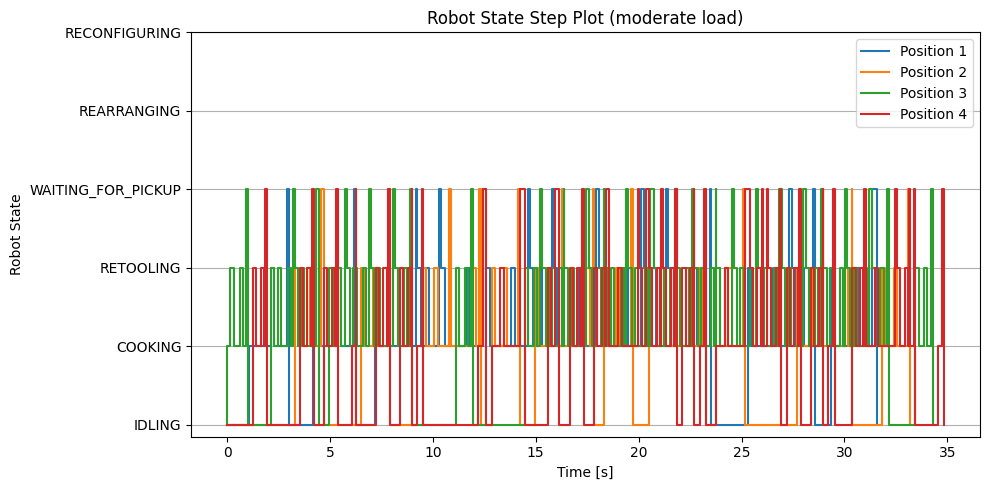

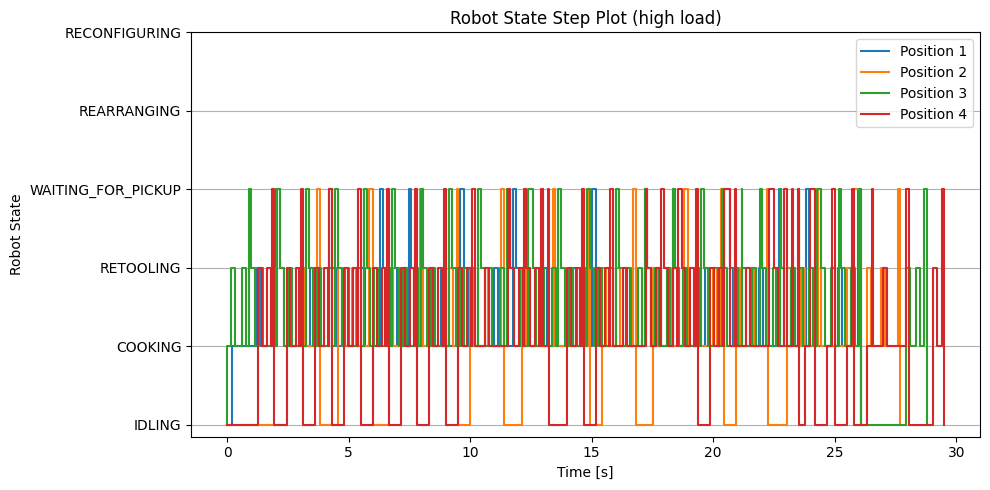

In [24]:
def plot_step_plot(statistics_df, title_addition):
    plt.figure(figsize=(10, 5))
    positions = sorted(statistics_df['Position'].unique().to_list())
    for pos in positions:
        pos_df = statistics_df.filter(pl.col('Position') == pos)
        plt.step(
            pos_df['Timestamp'].to_numpy() / 1e9,
            pos_df['State'].to_numpy(),
            where='post',
            label=f'Position {pos}'
        )

    # Map y-ticks to state names
    state_vals = sorted(ROBOT_STATE_NAME.keys())
    plt.yticks(state_vals, [ROBOT_STATE_NAME[v] for v in state_vals])

    plt.xlabel('Time [s]')
    plt.ylabel('Robot State')
    plt.title(f'Robot State Step Plot ({title_addition})')
    plt.grid(True, axis='y')
    plt.legend()
    plt.tight_layout()
    plt.show()

stat_dfs = [moderate_load_df, high_load_df]
titles = ['moderate load', 'high load']
for stat_df, title in zip(stat_dfs, titles):
    plot_step_plot(stat_df, title)